In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
from google.colab import files

uploaded = files.upload()

Saving student-performance-prediction-machine-learning-challenge.zip to student-performance-prediction-machine-learning-challenge.zip


In [8]:
import zipfile
import os

zip_file = "student-performance-prediction-machine-learning-challenge.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("student_data")

os.listdir("student_data")

['train.csv', 'sample_submission.csv', 'test.csv']

In [9]:
for root, dirs, files_list in os.walk("student_data"):
    print(root)
    for file in files_list:
        print("   ", file)

student_data
    train.csv
    sample_submission.csv
    test.csv


In [10]:
train_path = None

for root, dirs, files_list in os.walk("student_data"):
    for file in files_list:
        if file == "train.csv":
            train_path = os.path.join(root, file)

print("Файл:", train_path)

df = pd.read_csv(train_path)

print("Размер датасета:", df.shape)
df.head()

Файл: student_data/train.csv
Размер датасета: (16000, 19)


,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     16000 non-null  int64  
 1   student_id             16000 non-null  int64  
 2   age                    16000 non-null  int64  
 3   gender                 16000 non-null  object 
 4   study_hours_per_day    16000 non-null  float64
 5   sleep_hours            16000 non-null  float64
 6   phone_usage_hours      16000 non-null  float64
 7   social_media_hours     16000 non-null  float64
 8   youtube_hours          16000 non-null  float64
 9   gaming_hours           16000 non-null  float64
 10  breaks_per_day         16000 non-null  int64  
 11  coffee_intake_mg       16000 non-null  int64  
 12  exercise_minutes       16000 non-null  int64  
 13  assignments_completed  16000 non-null  int64  
 14  attendance_percentage  16000 non-null  float64
 15  st

In [12]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])

print("\nНазвания столбцов:")
print(df.columns.tolist())

Количество строк: 16000
Количество столбцов: 19

Названия столбцов:
['id', 'student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']


In [13]:
target = "productivity_score"

print("Целевая переменная:", target)

Целевая переменная: productivity_score


In [14]:
print(df.isnull().sum())

id                       0
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64


In [15]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

features = [col for col in numeric_columns if col != target]

print("Числовые признаки:")
print(features)

Числовые признаки:
['id', 'student_id', 'age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade']


In [16]:
X = df[features]
y = df[target]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
model_base = LinearRegression()

model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

In [19]:
mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print("БАЗОВАЯ МОДЕЛЬ")
print("----------------------")
print("MAE :", mae_base)
print("MSE :", mse_base)
print("RMSE:", rmse_base)
print("R²  :", r2_base)

БАЗОВАЯ МОДЕЛЬ
----------------------
MAE : 0.0024876036957918483
MSE : 8.24596452083356e-06
RMSE: 0.002871578750588874
R²  : 0.9999999686264099


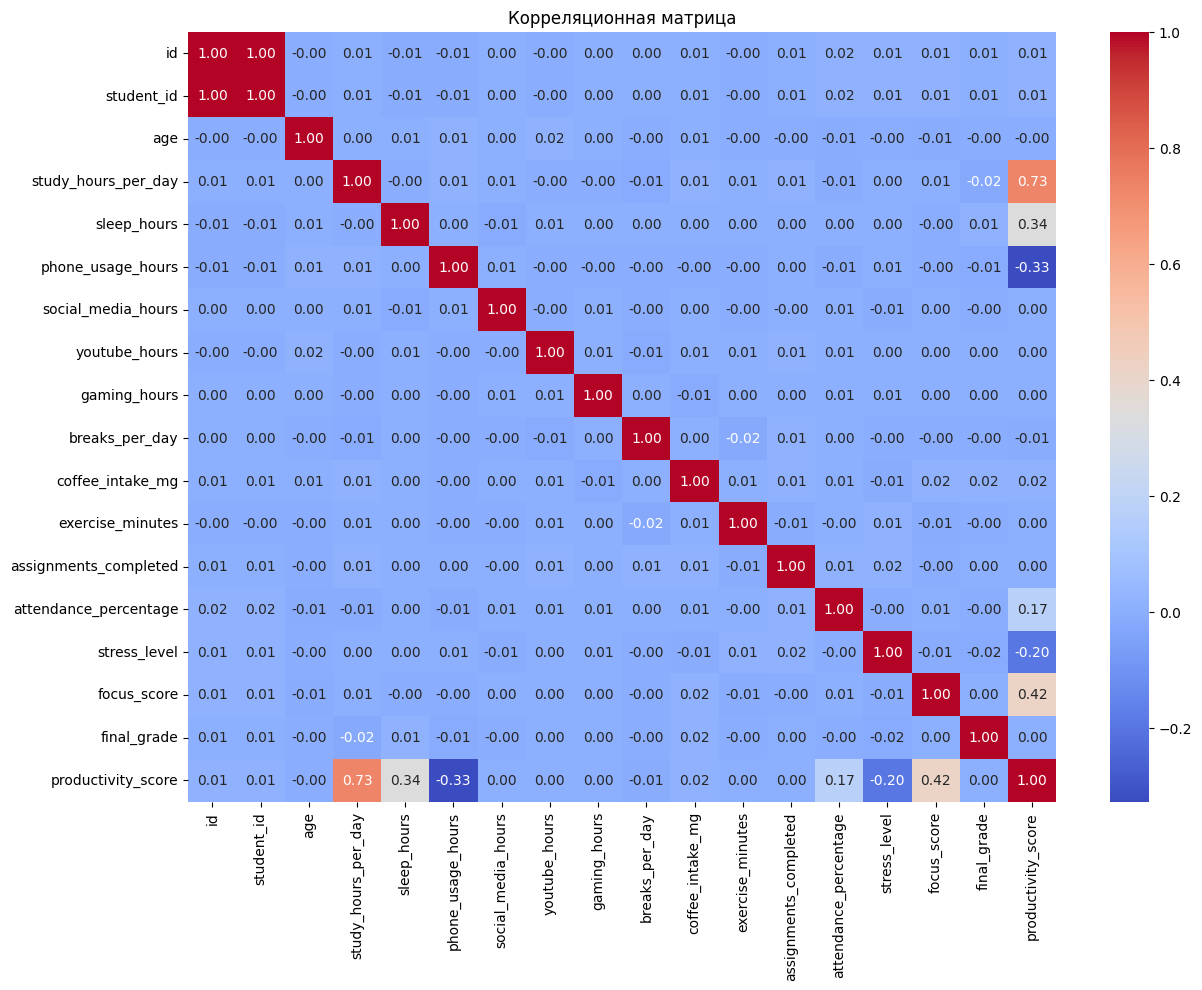

In [20]:
corr_matrix = df[features + [target]].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица")
plt.show()

In [21]:
correlation_threshold = 0.8

high_corr_pairs = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        corr_value = corr_matrix.loc[features[i], features[j]]

        if abs(corr_value) >= correlation_threshold:
            high_corr_pairs.append(
                (features[i], features[j], corr_value)
            )

print("Сильно коррелирующие признаки:")
for pair in high_corr_pairs:
    print(pair)

Сильно коррелирующие признаки:
('id', 'student_id', np.float64(1.0))


In [22]:
corr_features = df[features].corr().abs()

upper_triangle = corr_features.where(
    np.triu(np.ones(corr_features.shape), k=1).astype(bool)
)

features_to_remove = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.8)
]

print("Признаки, которые удаляем:")
print(features_to_remove)

Признаки, которые удаляем:
['student_id']


In [23]:
reduced_features = [
    feature
    for feature in features
    if feature not in features_to_remove
]

print("Признаки до сокращения:", len(features))
print("Признаки после сокращения:", len(reduced_features))

print("\nФинальный набор:")
print(reduced_features)

Признаки до сокращения: 17
Признаки после сокращения: 16

Финальный набор:
['id', 'age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade']


In [24]:
X_reduced = df[reduced_features]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
model_reduced = LinearRegression()

model_reduced.fit(X_train_red, y_train_red)

y_pred_reduced = model_reduced.predict(X_test_red)

In [26]:
mae_reduced = mean_absolute_error(y_test_red, y_pred_reduced)
mse_reduced = mean_squared_error(y_test_red, y_pred_reduced)
rmse_reduced = np.sqrt(mse_reduced)
r2_reduced = r2_score(y_test_red, y_pred_reduced)

print("СОКРАЩЁННАЯ МОДЕЛЬ")
print("----------------------")
print("MAE :", mae_reduced)
print("MSE :", mse_reduced)
print("RMSE:", rmse_reduced)
print("R²  :", r2_reduced)

СОКРАЩЁННАЯ МОДЕЛЬ
----------------------
MAE : 0.0024876036957937383
MSE : 8.245964520840827e-06
RMSE: 0.0028715787505901396
R²  : 0.9999999686264099


In [28]:
comparison = pd.DataFrame({
    "Модель": [
        "Базовая",
        "Сокращённая"
    ],
    "MAE": [
        mae_base,
        mae_reduced
    ],
    "RMSE": [
        rmse_base,
        rmse_reduced
    ],
    "R²": [
        r2_base,
        r2_reduced
    ]
})

comparison

,Модель,MAE,RMSE,R²
0,Базовая,0.002488,0.002872,1.0
1,Сокращённая,0.002488,0.002872,1.0


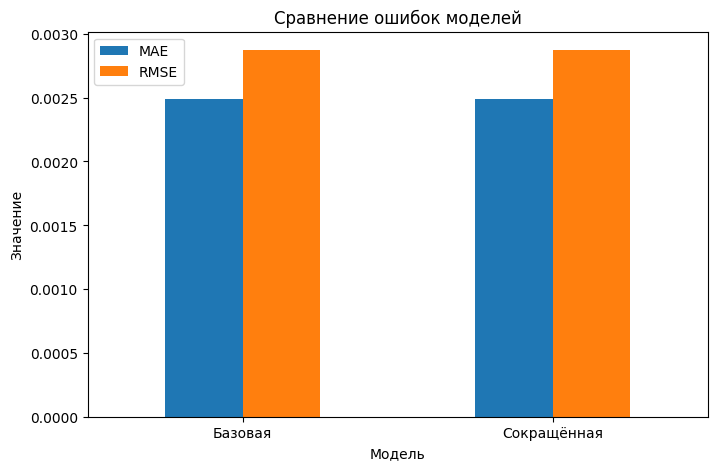

In [29]:
comparison.set_index("Модель")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Сравнение ошибок моделей")
plt.ylabel("Значение")
plt.xticks(rotation=0)
plt.show()

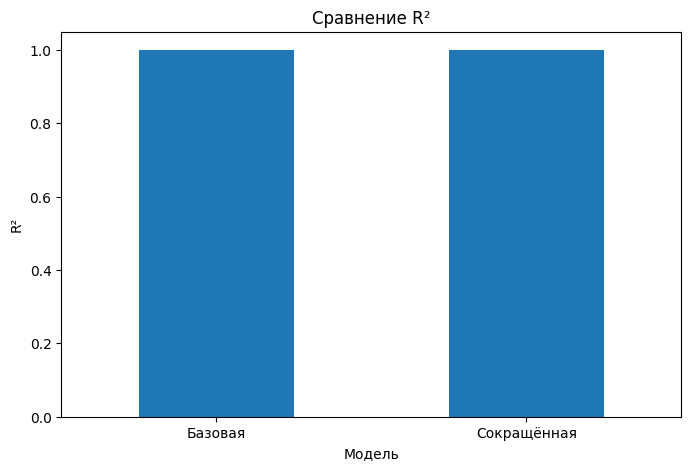

In [30]:
comparison.set_index("Модель")["R²"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Сравнение R²")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.show()

In [31]:
residuals = y_test_red - y_pred_reduced

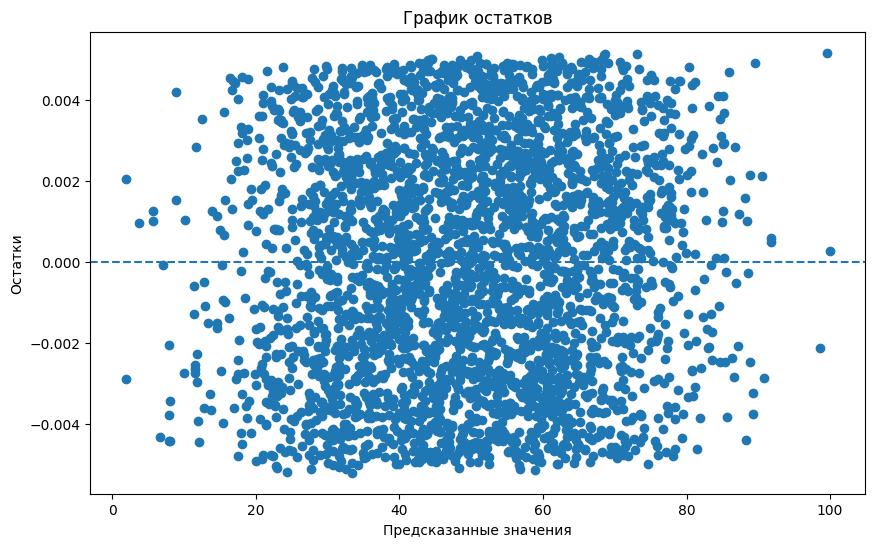

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred_reduced, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()

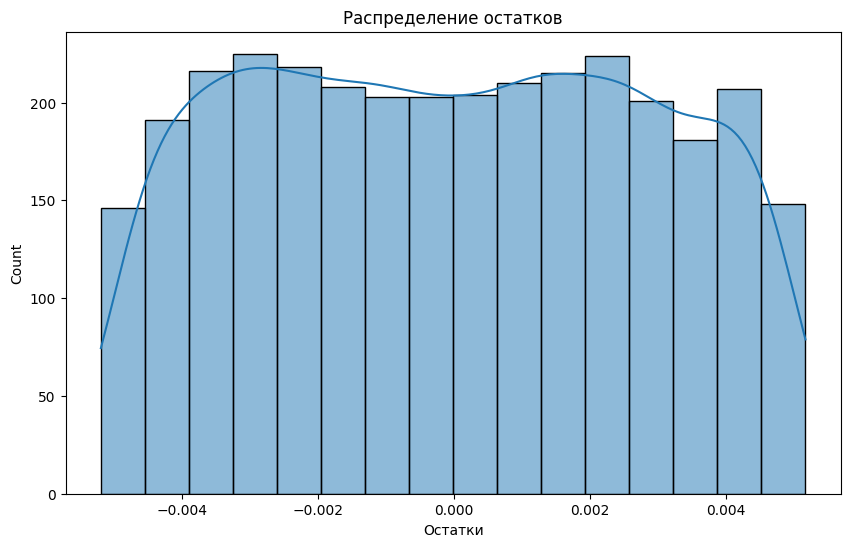

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Остатки")
plt.title("Распределение остатков")
plt.show()

В ходе работы была построена базовая модель линейной регрессии с использованием всех доступных числовых признаков. Для оценки качества модели использовались метрики MAE, RMSE и R².

На следующем этапе была исследована корреляция между признаками. Признаки с абсолютным коэффициентом корреляции выше 0.8 рассматривались как потенциально избыточные. На основании корреляционной матрицы был сформирован сокращённый набор признаков.

После этого была обучена вторая модель линейной регрессии на сокращённом наборе признаков. Метрики базовой и сокращённой моделей были сравнены.

Базовая модель:
MAE = [значение]
RMSE = [значение]
R² = [значение]

Сокращённая модель:
MAE = [значение]
RMSE = [значение]
R² = [значение]

По графику остатков было проверено наличие систематического паттерна. Если остатки распределены вокруг нулевой линии без выраженной структуры, это говорит об отсутствии явного нарушения предположений линейной модели.

Финальный набор признаков был выбран на основании анализа мультиколлинеарности и сравнения качества моделей. Такой подход позволяет уменьшить избыточность признаков, сохраняя приемлемое качество прогнозирования.


In [34]:
import zipfile
import os

zip_file = "student-performance-prediction-machine-learning-challenge.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("student_data")

for root, dirs, files in os.walk("student_data"):
    for file in files:
        print(os.path.join(root, file))

student_data/train.csv
student_data/sample_submission.csv
student_data/test.csv


In [35]:
import pandas as pd

df = pd.read_csv("student_data/train.csv")

print("Размер:", df.shape)
df.head()

Размер: (16000, 19)


,id,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,5894,5895,28,Other,4.56,7.61,1.70,7.23,3.80,3.18,2,256,102,14,52.72,6,68,70.48,55.29
1,3728,3729,18,Female,7.95,8.17,4.24,5.50,4.80,3.53,9,370,115,17,87.51,1,69,57.67,78.68
2,8958,8959,19,Male,6.06,9.02,3.17,5.08,5.09,3.74,5,250,33,9,72.39,8,57,72.51,60.66
3,7671,7672,21,Female,1.40,8.06,2.35,1.03,0.13,5.23,4,55,110,0,87.47,5,34,81.93,37.51
4,5999,6000,25,Male,9.27,7.39,10.68,5.21,3.43,5.38,11,436,66,17,47.66,5,37,49.11,50.72


In [36]:
# Посмотрим количество пропусков
print("Пропуски до обработки:")
print(df.isnull().sum())

Пропуски до обработки:
id                       0
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64


In [37]:
# Заполняем пропуски медианой только в числовых столбцах
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print("Пропуски после обработки:")
print(df.isnull().sum())

Пропуски после обработки:
id                       0
student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64


In [38]:
target = "productivity_score"

# ID не используем
exclude_columns = [
    "id",
    "student_id",
    target
]

features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in exclude_columns
]

print("Числовые признаки:")
for feature in features:
    print("-", feature)

print("\nКоличество признаков:", len(features))

Числовые признаки:
- age
- study_hours_per_day
- sleep_hours
- phone_usage_hours
- social_media_hours
- youtube_hours
- gaming_hours
- breaks_per_day
- coffee_intake_mg
- exercise_minutes
- assignments_completed
- attendance_percentage
- stress_level
- focus_score
- final_grade

Количество признаков: 15


In [39]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (12800, 15)
Размер тестовой выборки: (3200, 15)


In [40]:
model_base = LinearRegression()

model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

In [41]:
mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print("=== БАЗОВАЯ МОДЕЛЬ ===")
print(f"MAE  = {mae_base:.4f}")
print(f"MSE  = {mse_base:.4f}")
print(f"RMSE = {rmse_base:.4f}")
print(f"R²   = {r2_base:.4f}")

=== БАЗОВАЯ МОДЕЛЬ ===
MAE  = 0.0025
MSE  = 0.0000
RMSE = 0.0029
R²   = 1.0000


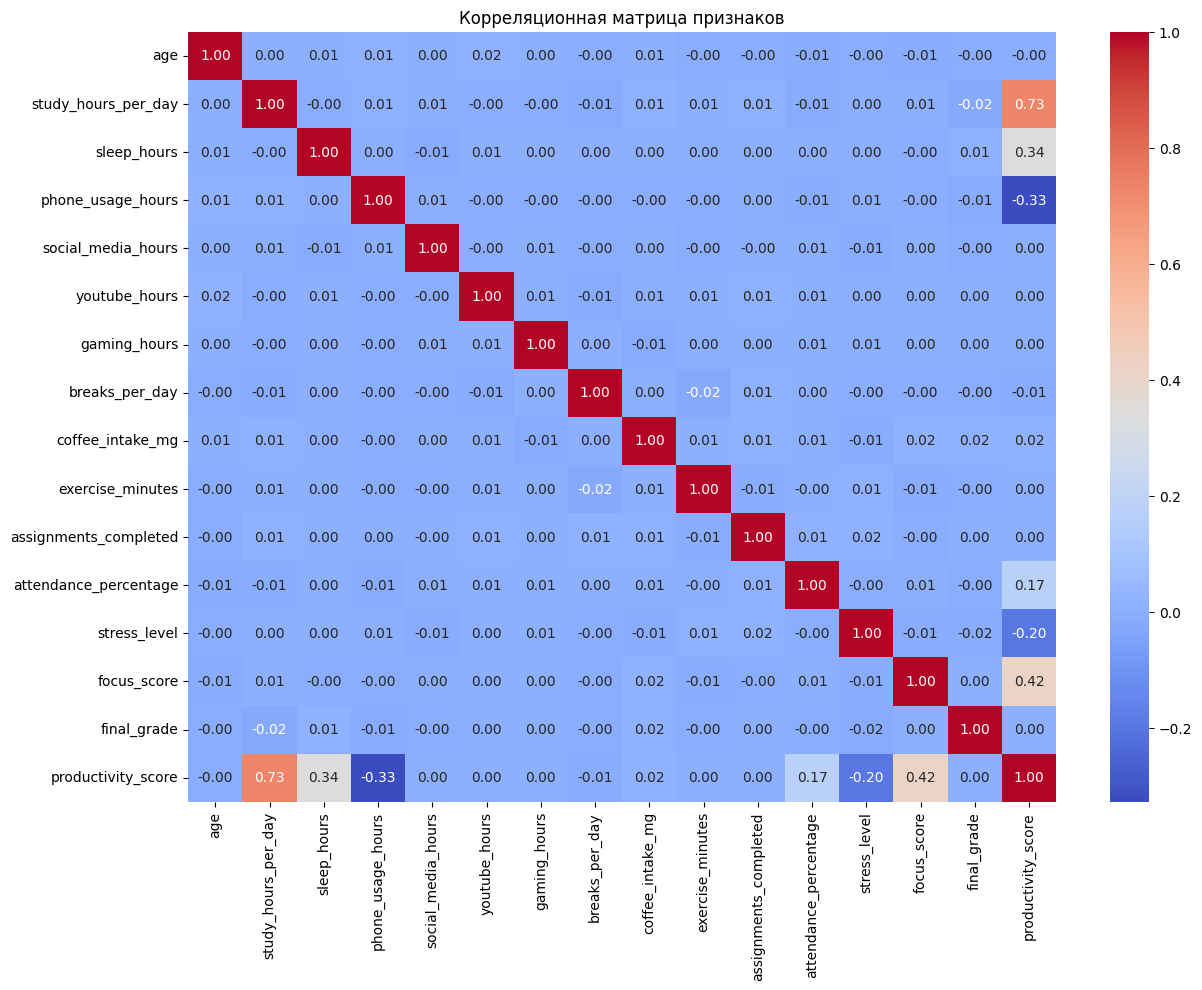

In [42]:
corr_matrix = df[features + [target]].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Корреляционная матрица признаков")
plt.show()

In [43]:
# Корреляция каждого признака с целевой переменной
target_corr = corr_matrix[target].sort_values(ascending=False)

print("Корреляция с productivity_score:")
print(target_corr)

Корреляция с productivity_score:
productivity_score       1.000000
study_hours_per_day      0.732300
focus_score              0.415125
sleep_hours              0.338570
attendance_percentage    0.174750
coffee_intake_mg         0.019559
assignments_completed    0.004874
youtube_hours            0.001988
exercise_minutes         0.001533
gaming_hours             0.000801
final_grade              0.000342
social_media_hours       0.000131
age                     -0.004461
breaks_per_day          -0.007023
stress_level            -0.195620
phone_usage_hours       -0.326874
Name: productivity_score, dtype: float64


In [44]:
correlation_threshold = 0.8

high_corr_pairs = []

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        corr_value = corr_matrix.loc[features[i], features[j]]

        if abs(corr_value) >= correlation_threshold:
            high_corr_pairs.append(
                (features[i], features[j], corr_value)
            )

print("=== СИЛЬНО КОРРЕЛИРУЮЩИЕ ПРИЗНАКИ ===")

if high_corr_pairs:
    for feature1, feature2, corr in high_corr_pairs:
        print(f"{feature1} <-> {feature2}: {corr:.3f}")
else:
    print("Сильных корреляций выше 0.8 не найдено.")

=== СИЛЬНО КОРРЕЛИРУЮЩИЕ ПРИЗНАКИ ===
Сильных корреляций выше 0.8 не найдено.


In [45]:
print("=== КОРРЕЛЯЦИЯ С PRODUCTIVITY_SCORE ===")
print(corr_matrix["productivity_score"].sort_values(ascending=False))

=== КОРРЕЛЯЦИЯ С PRODUCTIVITY_SCORE ===
productivity_score       1.000000
study_hours_per_day      0.732300
focus_score              0.415125
sleep_hours              0.338570
attendance_percentage    0.174750
coffee_intake_mg         0.019559
assignments_completed    0.004874
youtube_hours            0.001988
exercise_minutes         0.001533
gaming_hours             0.000801
final_grade              0.000342
social_media_hours       0.000131
age                     -0.004461
breaks_per_day          -0.007023
stress_level            -0.195620
phone_usage_hours       -0.326874
Name: productivity_score, dtype: float64


In [46]:
print("\n=== ТОП-5 ПРИЗНАКОВ ПО АБСОЛЮТНОЙ КОРРЕЛЯЦИИ ===")

target_correlations = (
    corr_matrix["productivity_score"]
    .drop("productivity_score")
    .abs()
    .sort_values(ascending=False)
)

print(target_correlations.head(5))


=== ТОП-5 ПРИЗНАКОВ ПО АБСОЛЮТНОЙ КОРРЕЛЯЦИИ ===
study_hours_per_day    0.732300
focus_score            0.415125
sleep_hours            0.338570
phone_usage_hours      0.326874
stress_level           0.195620
Name: productivity_score, dtype: float64


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[features].copy()

vif_data = pd.DataFrame()

vif_data["Признак"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

print(vif_data)

                  Признак       VIF
10  assignments_completed  1.001177
8        coffee_intake_mg  1.001175
14            final_grade  1.001139
12           stress_level  1.001078
1     study_hours_per_day  1.001006
7          breaks_per_day  1.000893
5           youtube_hours  1.000816
11  attendance_percentage  1.000716
0                     age  1.000707
9        exercise_minutes  1.000705
3       phone_usage_hours  1.000670
13            focus_score  1.000580
4      social_media_hours  1.000474
6            gaming_hours  1.000471
2             sleep_hours  1.000454


In [48]:
print("Признаки с VIF > 5:")

high_vif = vif_data[vif_data["VIF"] > 5]

if len(high_vif) == 0:
    print("Таких признаков нет.")
else:
    print(high_vif)

Признаки с VIF > 5:
Таких признаков нет.


In [49]:
target_corr = corr_matrix[target].drop(target)

reduced_features = target_corr[
    target_corr.abs() >= 0.1
].index.tolist()

print("Сокращённый набор признаков:")
for feature in reduced_features:
    print("-", feature)

print("\nКоличество признаков:", len(reduced_features))

Сокращённый набор признаков:
- study_hours_per_day
- sleep_hours
- phone_usage_hours
- attendance_percentage
- stress_level
- focus_score

Количество признаков: 6


In [50]:
X_reduced = df[reduced_features]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

model_reduced = LinearRegression()

model_reduced.fit(X_train_red, y_train_red)

y_pred_reduced = model_reduced.predict(X_test_red)

In [51]:
mae_reduced = mean_absolute_error(y_test_red, y_pred_reduced)
mse_reduced = mean_squared_error(y_test_red, y_pred_reduced)
rmse_reduced = np.sqrt(mse_reduced)
r2_reduced = r2_score(y_test_red, y_pred_reduced)

print("=== СОКРАЩЁННАЯ МОДЕЛЬ ===")
print(f"MAE  = {mae_reduced:.4f}")
print(f"MSE  = {mse_reduced:.4f}")
print(f"RMSE = {rmse_reduced:.4f}")
print(f"R²   = {r2_reduced:.4f}")

=== СОКРАЩЁННАЯ МОДЕЛЬ ===
MAE  = 0.0025
MSE  = 0.0000
RMSE = 0.0029
R²   = 1.0000


In [52]:
comparison = pd.DataFrame({
    "Модель": ["Базовая", "Сокращённая"],
    "MAE": [mae_base, mae_reduced],
    "RMSE": [rmse_base, rmse_reduced],
    "R²": [r2_base, r2_reduced]
})

print(comparison)

        Модель       MAE      RMSE   R²
0      Базовая  0.002488  0.002872  1.0
1  Сокращённая  0.002488  0.002872  1.0


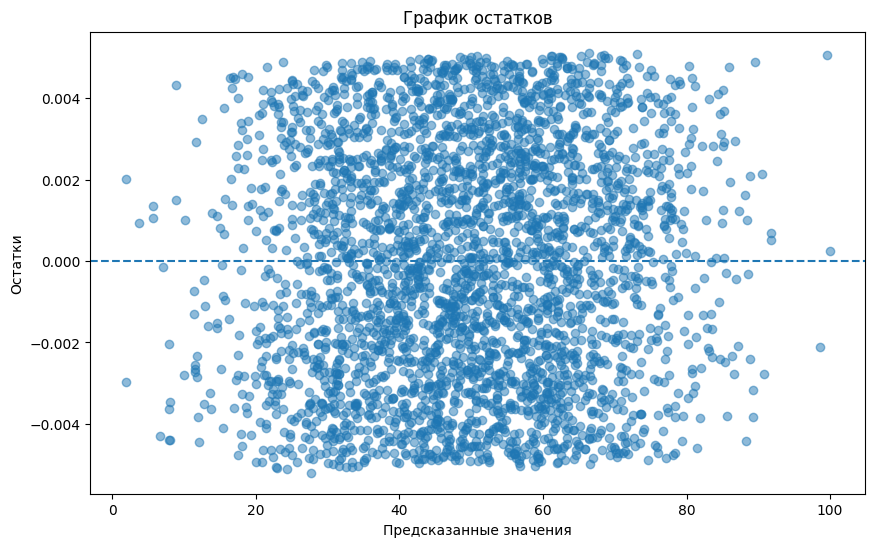

In [53]:
residuals = y_test_red - y_pred_reduced

plt.figure(figsize=(10, 6))

plt.scatter(y_pred_reduced, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()

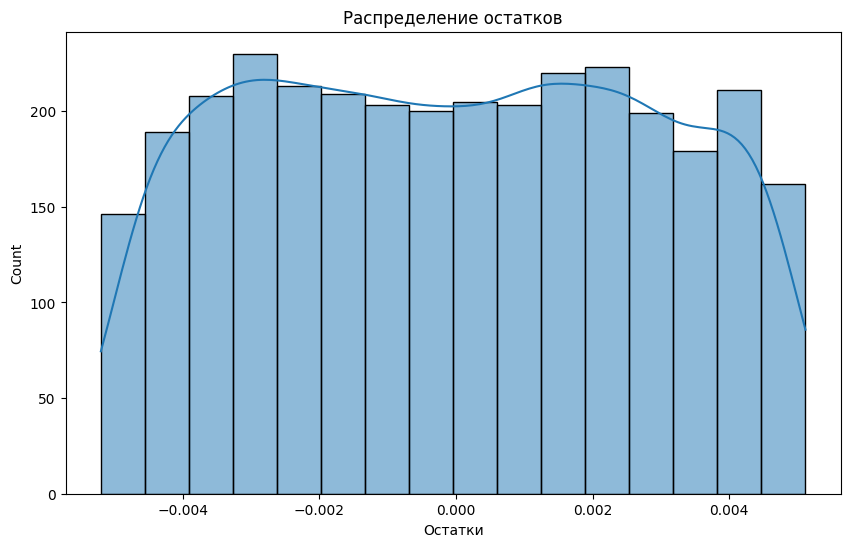

In [54]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Остатки")
plt.title("Распределение остатков")
plt.show()

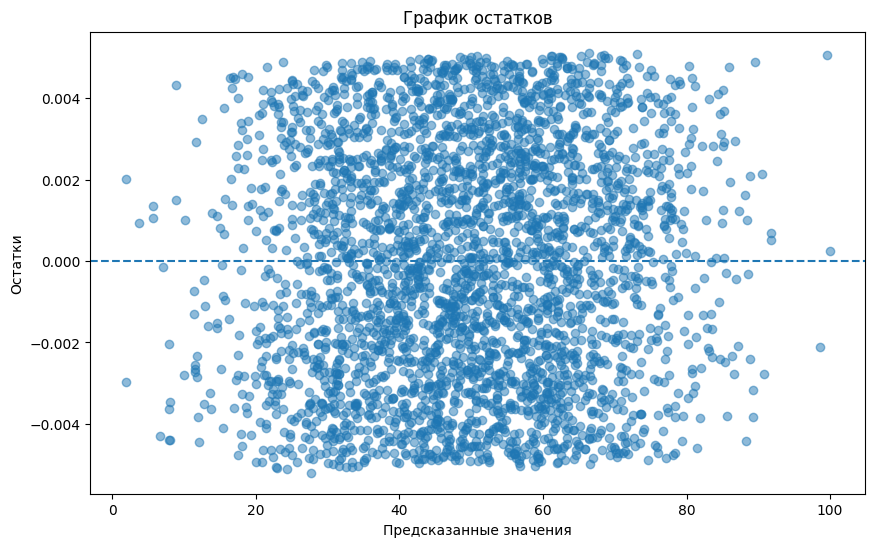

In [55]:
residuals = y_test_red - y_pred_reduced

plt.figure(figsize=(10, 6))

plt.scatter(y_pred_reduced, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")

plt.show()

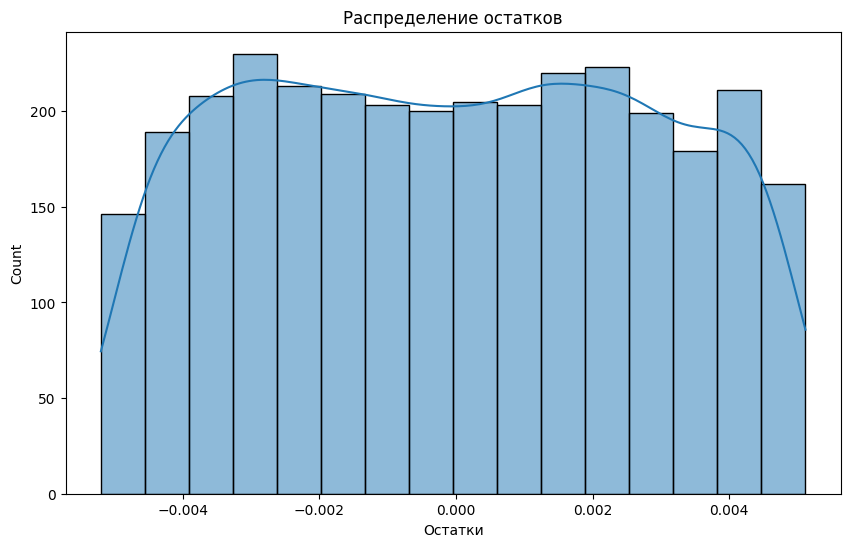

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Остатки")
plt.title("Распределение остатков")

plt.show()

In [57]:
print("Среднее остатков:", residuals.mean())
print("Минимальный остаток:", residuals.min())
print("Максимальный остаток:", residuals.max())
print("Стандартное отклонение:", residuals.std())

Среднее остатков: -3.659034634398331e-05
Минимальный остаток: -0.005201509889833034
Максимальный остаток: 0.005116297832245209
Стандартное отклонение: 0.002872027226464434


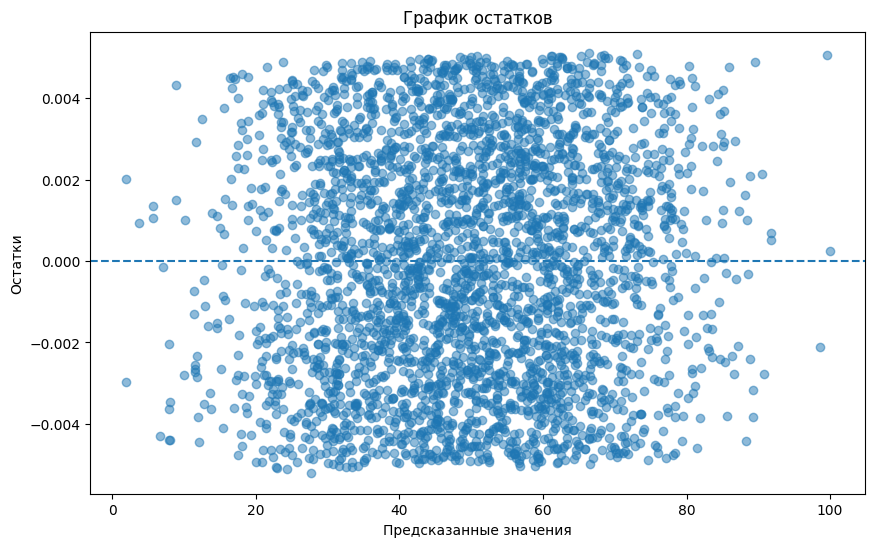

In [58]:
# Остатки модели
residuals = y_test_red - y_pred_reduced

# График остатков
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_reduced, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")
plt.show()

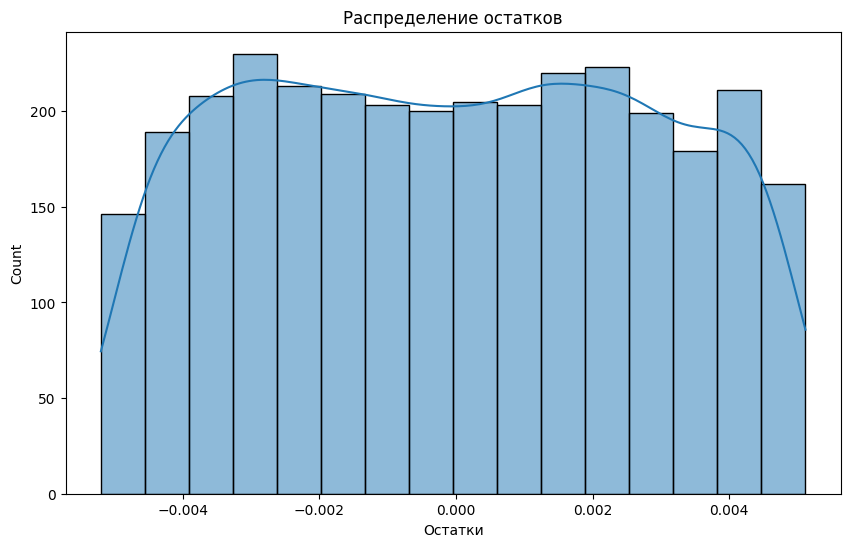

In [59]:
# Распределение остатков
plt.figure(figsize=(10, 6))

sns.histplot(residuals, kde=True)

plt.xlabel("Остатки")
plt.title("Распределение остатков")
plt.show()

In [60]:
# Статистика остатков
print("Среднее остатков:", residuals.mean())
print("Минимальный остаток:", residuals.min())
print("Максимальный остаток:", residuals.max())
print("Стандартное отклонение:", residuals.std())


Среднее остатков: -3.659034634398331e-05
Минимальный остаток: -0.005201509889833034
Максимальный остаток: 0.005116297832245209
Стандартное отклонение: 0.002872027226464434
